In [9]:
# 1. Imports
#%pip install numpy pandas matplotlib scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [10]:
# 2. Load dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame  # pandas DataFrame

print("Columns:", df.columns.tolist())
df.head()

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [11]:
# 3. Select features and target
feature_cols = ["MedInc", "AveRooms", "AveOccup", "HouseAge"]
target_col = "MedHouseVal"

X = df[feature_cols].values  # shape (m, n)
y = df[target_col].values    # shape (m, )

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (20640, 4)
y shape: (20640,)


In [12]:
# 4. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (16512, 4) (16512,)
Test shape: (4128, 4) (4128,)


In [13]:
# 5. Normalization utilities

def normalize_features(X):
    """
    Mean normalization:
    X_norm = (X - mu) / (max - min)
    Returns X_norm, mu, ptp (range)
    """
    mu = np.mean(X, axis=0)
    ptp = np.ptp(X, axis=0)  # max - min per column
    X_norm = (X - mu) / ptp
    return X_norm, mu, ptp

def apply_normalization(X, mu, ptp):
    return (X - mu) / ptp

# Fit normalization on training data only
X_train_norm, mu, ptp = normalize_features(X_train)

# Apply same normalization to test data
X_test_norm = apply_normalization(X_test, mu, ptp)

print("Peak to Peak range by column in Raw        X:", np.ptp(X_train, axis=0))
print("Peak to Peak range by column in Normalized X:", np.ptp(X_train_norm, axis=0))


Peak to Peak range by column in Raw        X: [  14.5002      141.02020202 1242.64102564   51.        ]
Peak to Peak range by column in Normalized X: [1. 1. 1. 1.]


In [19]:
# Add Polynomial (More) Features

def add_polynomial_features(X, degree=2):
    """
    Generate polynomial features up to given degree.
    For each column: x, x^2, x^3, ...
    """
    X_poly = X.copy()
    for d in range(2, degree + 1):
        X_poly = np.concatenate([X_poly, X ** d], axis=1)
    return X_poly

In [20]:
# Add polynomial features
degree = 2
X_train_poly = add_polynomial_features(X_train_norm, degree)
X_test_poly  = add_polynomial_features(X_test_norm, degree)

print("Original shape:", X_train_norm.shape)
print("With polynomial features:", X_train_poly.shape)

Original shape: (16512, 4)
With polynomial features: (16512, 8)


In [21]:
X_used = X_train_poly
X_test_used = X_test_poly
# train using these instead of x_train_norm

In [14]:
# 6. Linear regression utilities (NumPy, no sklearn model)

def compute_cost_linear_reg(X, y, w, b, lambda_):
    """
    Compute cost for linear regression:
    J(w, b) = (1 / (2m)) * sum( (Xw + b - y)^2 )
    """
    m = X.shape[0]
    preds = X @ w + b
    error = preds - y
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    reg_cost = (lambda_ / (2 * m)) * np.sum(w ** 2)
    return cost + reg_cost

def compute_gradient_linear_reg(X, y, w, b, lambda_):
    """
    Compute gradient of the cost w.r.t. w, b.
    """
    m = X.shape[0]
    preds = X @ w + b
    error = preds - y
    dj_dw = (1/m) * (X.T @ error) + (lambda_/m) * w
    dj_db = (1 / m) * np.sum(error)
    return dj_dw, dj_db

def gradient_descent_linear(X, y, w_in, b_in, alpha, num_iters, verbose=True):
    """
    Perform gradient descent to optimize w, b.
    """
    w = w_in.copy()
    b = float(b_in)
    J_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_linear(X, y, w, b)

        # update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        # save cost
        cost = compute_cost_linear(X, y, w, b)
        J_history.append(cost)

        # optionally print progress
        if verbose and i % max(1, (num_iters // 10)) == 0:
            print(f"Iteration {i:4d}: Cost {cost:0.4f}")

    return w, b, J_history

def predict_linear(X, w, b):
    return X @ w + b


In [22]:
# 7. Train the linear regression model
m, n = X_used.shape
print("Num training examples:", m, "| Num features:", n)

# Initialize parameters
w_init = np.zeros(n)
b_init = 0.0

alpha = 0.1        # learning rate (for normalized features, 0.01–0.1 is reasonable)
num_iters = 500    # you can increase if needed

w_trained, b_trained, J_history = gradient_descent_linear(
    X_used, y_train, w_init, b_init, alpha, num_iters, verbose=True
)

print("\nTrained parameters:")
print("w:", w_trained)
print("b:", b_trained)


Num training examples: 16512 | Num features: 8
Iteration    0: Cost 2.4040
Iteration   50: Cost 0.6100
Iteration  100: Cost 0.5639
Iteration  150: Cost 0.5255
Iteration  200: Cost 0.4935
Iteration  250: Cost 0.4667
Iteration  300: Cost 0.4444
Iteration  350: Cost 0.4257
Iteration  400: Cost 0.4100
Iteration  450: Cost 0.3969

Trained parameters:
w: [ 3.51621544  0.08990584 -0.01549443  0.62783506  0.60734024  0.00876732
 -0.00576     0.32871249]
b: 2.0416549360937872


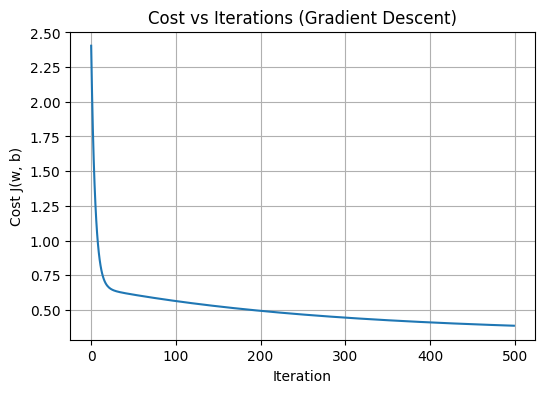

In [23]:
# 8. Plot cost history
plt.figure(figsize=(6,4))
plt.plot(J_history)
plt.xlabel("Iteration")
plt.ylabel("Cost J(w, b)")
plt.title("Cost vs Iterations (Gradient Descent)")
plt.grid(True)
plt.show()


In [17]:
# 9. Evaluation: MSE and R^2 on train and test

# Use normalized features for prediction
y_train_pred = predict_linear(X_train_norm, w_trained, b_trained)
y_test_pred  = predict_linear(X_test_norm,  w_trained, b_trained)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test  = mean_squared_error(y_test,  y_test_pred)

r2_train = r2_score(y_train, y_train_pred)
r2_test  = r2_score(y_test,  y_test_pred)

print(f"Train MSE: {mse_train:.4f}, R^2: {r2_train:.4f}")
print(f"Test  MSE: {mse_test:.4f}, R^2: {r2_test:.4f}")


Train MSE: 0.7765, R^2: 0.4192
Test  MSE: 0.7743, R^2: 0.4091


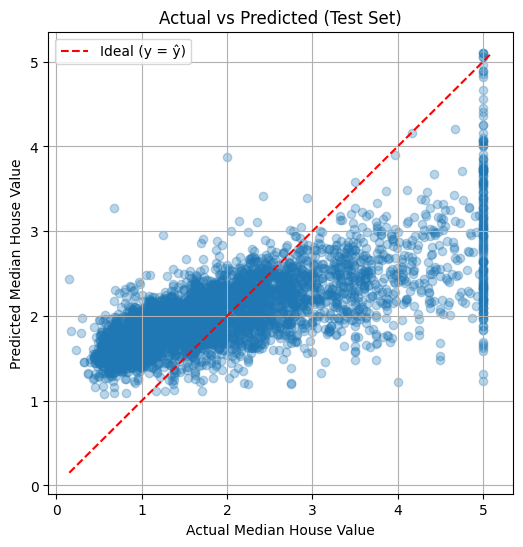

In [18]:
# 10. Scatter plot: predicted vs actual on test data

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.3)
max_val = max(y_test.max(), y_test_pred.max())
min_val = min(y_test.min(), y_test_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Ideal (y = ŷ)")
plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs Predicted (Test Set)")
plt.legend()
plt.grid(True)
plt.show()
